# Stage 1 — Transfer Learning: MobileNetV2 vs EfficientNetB0

Порівняння з CNN з нуля (`stage1_binary.ipynb`).

**Два етапи навчання:**
- Фаза 1 — заморожена база, тренується лише голова (`LR=1e-3`)
- Фаза 2 — розморожуються останні `UNFREEZE_LAYERS` шарів (`LR=1e-5`)

**Препроцесинг порівняно зі stage1:**
| Модель | Нормалізація | Діапазон |
|---|---|---|
| Stage1 CNN | `rescale=1/255` (ImageDataGenerator) | `[0, 1]` |
| MobileNetV2 | `mobilenet_v2.preprocess_input` | `[-1, 1]` |
| EfficientNetB0 | `efficientnet.preprocess_input` | `[-1, 1]` |

Додатково: вхід масштабується з `150×150` → `224×224` у пайплайні.

In [1]:
import numpy as np
import os
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import cm as mpl_cm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)
print('TF version:', tf.__version__)

TF version: 2.21.0


In [2]:
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 32
EPOCHS_FROZEN  = 10
EPOCHS_FINE    = 15
LR_FROZEN      = 1e-3
LR_FINE        = 1e-5
UNFREEZE_LAYERS = 30

CACHE_X = 'dataset/cache_X.npy'
CACHE_Y = 'dataset/cache_Y.npy'

## Завантаження даних (ідентично stage1)

In [3]:
X = np.load(CACHE_X)
y = np.load(CACHE_Y)
if X.dtype != np.uint8:
    X = (X * 255).astype(np.uint8)
print(f'Завантажено: {X.shape}  dtype={X.dtype}')
print(f'Динозаврів: {(y==1).sum()}  |  Не-динозаврів: {(y==0).sum()}')

Завантажено: (29748, 150, 150, 3)  dtype=uint8
Динозаврів: 12618  |  Не-динозаврів: 17130


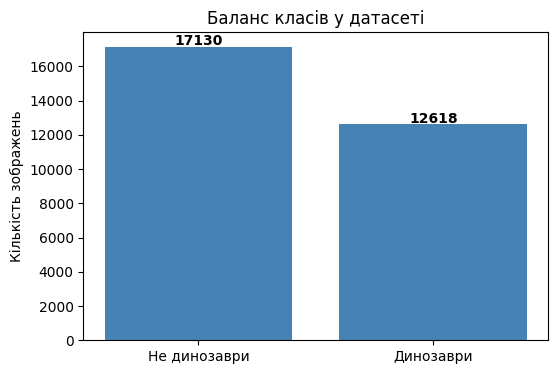

In [4]:
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(6, 4))
plt.bar(['Не динозаври', 'Динозаври'], counts, color=['steelblue', 'steelblue'])
plt.title('Баланс класів у датасеті')
plt.ylabel('Кількість зображень')
for i, c in enumerate(counts):
    plt.text(i, c + 100, str(c), ha='center', fontweight='bold')
plt.show()

## Розбивка (random_state=42, stratify — ідентично stage1)

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

Train: (20823, 150, 150, 3)  Val: (4462, 150, 150, 3)  Test: (4463, 150, 150, 3)


In [6]:
classes = np.unique(y_train)
class_weights_arr = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, class_weights_arr))
print('Class weights:', class_weights)

Class weights: {np.int32(0): np.float64(0.8682762071553666), np.int32(1): np.float64(1.1788383152173914)}


## tf.data pipeline

In [7]:
def make_dataset(X_data, y_data, batch_size, preprocess_fn, augment=False):
    def process(img, label):
        img = tf.cast(img, tf.float32)
        img = tf.image.resize(img, IMG_SIZE)
        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, max_delta=0.15)
            img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
            img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
            img = tf.clip_by_value(img, 0.0, 255.0)
        img = preprocess_fn(img)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((X_data, y_data))
    if augment:
        ds = ds.shuffle(buffer_size=len(X_data), seed=42)
    ds = ds.map(process, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

## Helpers — графіки, confusion matrix, predictions

In [8]:
def plot_history(hist1, hist2, model_name):
    n1 = len(hist1.history['accuracy'])
    acc      = hist1.history['accuracy']     + hist2.history['accuracy']
    val_acc  = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss     = hist1.history['loss']         + hist2.history['loss']
    val_loss = hist1.history['val_loss']     + hist2.history['val_loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (tr, vl), title in zip(
        [ax1, ax2],
        [(acc, val_acc), (loss, val_loss)],
        ['Accuracy', 'Loss']
    ):
        ax.plot(tr,  label='Train')
        ax.plot(vl,  label='Val')
        ax.axvline(n1 - 0.5, color='red', linestyle='--', alpha=0.7, label='Fine-tune start')
        ax.set_title(f'{model_name} — {title}')
        ax.set_xlabel('Epoch')
        ax.legend()
    plt.tight_layout()
    plt.show()


def evaluate_model(model, test_ds, y_true, model_name):
    y_pred_prob = model.predict(test_ds, verbose=0).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    cm_val = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(cm_val, display_labels=['Не динозавр', 'Динозавр'])
    disp.plot(cmap='Blues')
    plt.title(f'{model_name} — Матриця плутанини')
    plt.show()

    tp, fp = cm_val[1, 1], cm_val[0, 1]
    fn, tn = cm_val[1, 0], cm_val[0, 0]
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    accuracy  = (tp + tn) / len(y_true)

    print(f'Accuracy:  {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'F1-score:  {f1:.4f}')

    return y_pred_prob, dict(accuracy=accuracy, precision=precision, recall=recall, f1=f1)


def show_predictions(X_data, y_true, y_pred_prob, model_name):
    class_names = ['Не динозавр', 'Динозавр']
    indices = random.sample(range(len(X_data)), 10)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        prob = float(y_pred_prob[idx])
        pred_label = int(prob >= 0.5)
        true_label = int(y_true[idx])
        color = 'green' if pred_label == true_label else 'red'
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_data[idx])
        plt.axis('off')
        plt.title(
            f'Іст: {class_names[true_label]}\nПред: {class_names[pred_label]}\n({prob:.2f})',
            fontsize=9, color=color
        )
    plt.suptitle(f'{model_name} — Приклади передбачень', fontsize=12)
    plt.tight_layout()
    plt.show()

## Grad-CAM helpers

In [9]:
def make_gradcam_heatmap(img_batch, grad_model):
    """img_batch: (1, H, W, 3) already preprocessed float32."""
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_batch, tf.float32)
        tape.watch(img_tensor)
        conv_output, preds = grad_model(img_tensor, training=False)
        tape.watch(conv_output)
        class_channel = preds[:, 0]
    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def show_gradcam(X_data, y_true, y_pred_prob, grad_model, preprocess_fn, model_name):
    high_conf = np.where((y_true == 1) & (y_pred_prob > 0.8))[0]
    if len(high_conf) < 4:
        high_conf = np.where(y_true == 1)[0]
    sample_idx = high_conf[:4]
    n = len(sample_idx)

    fig, axes = plt.subplots(n, 3, figsize=(13, 4 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(sample_idx):
        img_orig = X_data[idx]  # uint8 150x150
        prob = float(y_pred_prob[idx])

        img_f    = tf.cast(img_orig, tf.float32)
        img_res  = tf.image.resize(img_f, IMG_SIZE)
        img_prep = preprocess_fn(img_res)
        img_b    = tf.expand_dims(img_prep, 0)

        heatmap  = make_gradcam_heatmap(img_b, grad_model)

        h, w = img_orig.shape[:2]
        hm_r = np.array(tf.image.resize(heatmap[..., np.newaxis], (h, w)))[..., 0]
        hm_c = np.uint8(255 * mpl_cm.jet(hm_r)[..., :3])
        blended = np.uint8(hm_c * 0.4 + img_orig * 0.6)

        axes[row, 0].imshow(img_orig)
        axes[row, 0].set_title(f'Оригінал\n{prob:.1%}', fontsize=11)
        axes[row, 0].axis('off')
        axes[row, 1].imshow(heatmap, cmap='jet')
        axes[row, 1].set_title('Grad-CAM', fontsize=11)
        axes[row, 1].axis('off')
        axes[row, 2].imshow(blended)
        axes[row, 2].set_title('Overlay', fontsize=11)
        axes[row, 2].axis('off')

    plt.suptitle(f'Grad-CAM: {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Model builder (feature_extractor підхід для Grad-CAM)

In [12]:
def build_transfer_model(base_fn, name):
    """
    Повертає (model, grad_model, base).
    grad_model: input → [last_conv_output, sigmoid_output]
    """
    base = base_fn(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = False

    last_conv = next(l for l in reversed(base.layers)
                     if isinstance(l, tf.keras.layers.Conv2D))
    print(f'[{name}] Last Conv2D: {last_conv.name}  output: {last_conv.output.shape}')

    # feature_extractor виводить і last_conv_out, і фінальний base_out
    feat_extractor = tf.keras.Model(
        inputs=base.input,
        outputs=[last_conv.output, base.output],
        name=f'{name}_feat'
    )

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), name='img')
    conv_out, base_out = feat_extractor(inputs, training=False)

    x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(base_out)
    x = tf.keras.layers.Dropout(0.3, name='drop')(x)
    x = tf.keras.layers.Dense(128, activation='relu', name='dense')(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='out')(x)

    model      = tf.keras.Model(inputs, outputs,             name=name)
    grad_model = tf.keras.Model(inputs, [conv_out, outputs], name=f'{name}_grad')

    return model, grad_model, base


def get_callbacks_phase1():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc', mode='max', patience=4,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2,
            min_lr=1e-6, verbose=1)
    ]


def get_callbacks_phase2():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc', mode='max', patience=5,
            restore_best_weights=True, verbose=1)
    ]


COMPILE_METRICS = [
    'accuracy',
    tf.keras.metrics.AUC(name='auc'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]

---
## MobileNetV2

In [13]:
mobilenet_preprocess = tf.keras.applications.mobilenet_v2.preprocess_input


mobilenet_model, mobilenet_grad, mobilenet_base = build_transfer_model(
    tf.keras.applications.MobileNetV2, 'MobileNetV2'
)

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FROZEN),
    loss='binary_crossentropy',
    metrics=COMPILE_METRICS
)
mobilenet_model.summary()

[MobileNetV2] Last Conv2D: Conv_1  output: (None, 7, 7, 1280)


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img (InputLayer)                │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV2_feat (Functional)   │ [(None, 7, 7, 1280),   │     2,257,984 │
│                                 │ (None, 7, 7, 1280)]    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop (Dropout)                  │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
mobilenet_train_ds = make_dataset(X_train, y_train, BATCH_SIZE, mobilenet_preprocess, augment=True)
mobilenet_val_ds   = make_dataset(X_val,   y_val,   BATCH_SIZE, mobilenet_preprocess, augment=False)
mobilenet_test_ds  = make_dataset(X_test,  y_test,  BATCH_SIZE, mobilenet_preprocess, augment=False)

### Фаза 1 — frozen base

In [ ]:
print('=== MobileNetV2  Phase 1: Frozen base ===')
mobilenet_hist1 = mobilenet_model.fit(
    mobilenet_train_ds,
    validation_data=mobilenet_val_ds,
    epochs=EPOCHS_FROZEN,
    class_weight=class_weights,
    callbacks=get_callbacks_phase1(),
    verbose=2
)

=== MobileNetV2  Phase 1: Frozen base ===
Epoch 1/10
651/651 - 640s - 983ms/step - accuracy: 0.9305 - auc: 0.9816 - loss: 0.1734 - precision: 0.9032 - recall: 0.9365 - val_accuracy: 0.9639 - val_auc: 0.9929 - val_loss: 0.1049 - val_precision: 0.9606 - val_recall: 0.9540 - learning_rate: 0.0010
Epoch 2/10


KeyboardInterrupt: 

### Фаза 2 — fine-tune

In [ ]:
for layer in mobilenet_base.layers[-UNFREEZE_LAYERS:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINE),
    loss='binary_crossentropy',
    metrics=COMPILE_METRICS
)

trainable_count = sum(1 for l in mobilenet_base.layers if l.trainable)
print(f'Trainable layers in base: {trainable_count}')

print('=== MobileNetV2  Phase 2: Fine-tune ===')
mobilenet_hist2 = mobilenet_model.fit(
    mobilenet_train_ds,
    validation_data=mobilenet_val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weights,
    callbacks=get_callbacks_phase2(),
    verbose=2
)

In [ ]:
mobilenet_model.save('models/stage1_mobilenetv2.keras')
print('Збережено: models/stage1_mobilenetv2.keras')

### MobileNetV2 — результати

In [ ]:
plot_history(mobilenet_hist1, mobilenet_hist2, 'MobileNetV2')

In [ ]:
mobilenet_pred_prob, mobilenet_metrics = evaluate_model(
    mobilenet_model, mobilenet_test_ds, y_test, 'MobileNetV2'
)

In [ ]:
show_predictions(X_test, y_test, mobilenet_pred_prob, 'MobileNetV2')

In [ ]:
show_gradcam(X_test, y_test, mobilenet_pred_prob,
             mobilenet_grad, mobilenet_preprocess, 'MobileNetV2')

---
## EfficientNetB0

In [ ]:
efficientnet_preprocess = tf.keras.applications.efficientnet.preprocess_input

efficientnet_model, efficientnet_grad, efficientnet_base = build_transfer_model(
    tf.keras.applications.EfficientNetB0, 'EfficientNetB0'
)

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FROZEN),
    loss='binary_crossentropy',
    metrics=COMPILE_METRICS
)
efficientnet_model.summary()

In [ ]:
efficientnet_train_ds = make_dataset(X_train, y_train, BATCH_SIZE, efficientnet_preprocess, augment=True)
efficientnet_val_ds   = make_dataset(X_val,   y_val,   BATCH_SIZE, efficientnet_preprocess, augment=False)
efficientnet_test_ds  = make_dataset(X_test,  y_test,  BATCH_SIZE, efficientnet_preprocess, augment=False)

### Фаза 1 — frozen base

In [ ]:
print('=== EfficientNetB0  Phase 1: Frozen base ===')
efficientnet_hist1 = efficientnet_model.fit(
    efficientnet_train_ds,
    validation_data=efficientnet_val_ds,
    epochs=EPOCHS_FROZEN,
    class_weight=class_weights,
    callbacks=get_callbacks_phase1(),
    verbose=2
)

### Фаза 2 — fine-tune

In [ ]:
for layer in efficientnet_base.layers[-UNFREEZE_LAYERS:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINE),
    loss='binary_crossentropy',
    metrics=COMPILE_METRICS
)

trainable_count = sum(1 for l in efficientnet_base.layers if l.trainable)
print(f'Trainable layers in base: {trainable_count}')

print('=== EfficientNetB0  Phase 2: Fine-tune ===')
efficientnet_hist2 = efficientnet_model.fit(
    efficientnet_train_ds,
    validation_data=efficientnet_val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weights,
    callbacks=get_callbacks_phase2(),
    verbose=2
)

In [ ]:
efficientnet_model.save('models/stage1_efficientnetb0.keras')
print('Збережено: models/stage1_efficientnetb0.keras')

### EfficientNetB0 — результати

In [ ]:
plot_history(efficientnet_hist1, efficientnet_hist2, 'EfficientNetB0')

In [ ]:
efficientnet_pred_prob, efficientnet_metrics = evaluate_model(
    efficientnet_model, efficientnet_test_ds, y_test, 'EfficientNetB0'
)

In [ ]:
show_predictions(X_test, y_test, efficientnet_pred_prob, 'EfficientNetB0')

In [ ]:
show_gradcam(X_test, y_test, efficientnet_pred_prob,
             efficientnet_grad, efficientnet_preprocess, 'EfficientNetB0')

---
## Порівняльна таблиця

In [ ]:
# Stage1 результати з confusion matrix (epoch 28, test set)
cm_s1 = [[2028, 542], [78, 1815]]
tp1, fp1, fn1, tn1 = cm_s1[1][1], cm_s1[0][1], cm_s1[1][0], cm_s1[0][0]
s1_prec = tp1 / (tp1 + fp1)
s1_rec  = tp1 / (tp1 + fn1)
s1_f1   = 2 * s1_prec * s1_rec / (s1_prec + s1_rec)
s1_acc  = (tp1 + tn1) / (tp1 + fp1 + fn1 + tn1)
s1_auc  = 0.9608  # best val_auc epoch 28

rows = [
    ('Stage1 CNN з нуля',  s1_acc,                         s1_auc,  s1_prec,                         s1_rec,                         s1_f1),
    ('MobileNetV2',        mobilenet_metrics['accuracy'],   None,    mobilenet_metrics['precision'],   mobilenet_metrics['recall'],    mobilenet_metrics['f1']),
    ('EfficientNetB0',     efficientnet_metrics['accuracy'],None,    efficientnet_metrics['precision'],efficientnet_metrics['recall'], efficientnet_metrics['f1']),
]

print(f'{'Модель':<24} {'Accuracy':>9} {'Val AUC':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}')
print('-' * 72)
for name, acc, auc, prec, rec, f1 in rows:
    auc_str = f'{auc:.4f}' if auc else '  —    '
    print(f'{name:<24} {acc:>9.4f} {auc_str:>9} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}')
print('-' * 72)